In [782]:
import numpy as np
import pandas as pd

# Parameters
mu, sigma = 100, 15 
students = 100
num_of_questions = 10
reinforcement_questions = 5

WEIGHT = 20
PASS_THRESHOLD = 0.5
MAX_ATTEMPTS = 5

DIFFICULTY = ["easy", "medium", "hard"]
PROBABILITIES = [0.7, 0.2, 0.1]
REINFORCEMENT_PROB = [0.8, 0.2, 0.0]

IQ_QUANTILES = {
    "easy": 0.10,
    "medium": 0.50,
    "hard": 0.90
}

In [783]:
# %%
def generate_students(n):
    iq_scores = np.random.normal(mu, sigma, n)
    return [{"iq": iq, "learning": 50} for iq in iq_scores]

student_list = generate_students(students)

In [784]:
# %%
def generate_questions(n, probs):
    return list(np.random.choice(DIFFICULTY, size=n, p=probs))

In [785]:
# %%
def compute_probability(student, difficulty):
    iq = student["iq"]
    learning = student["learning"]
    quantile = IQ_QUANTILES[difficulty]
    
    A_i = (iq + learning) / (WEIGHT * quantile * 100)
    return min(1, A_i)

In [786]:
# %%
def answer_question(student, difficulty):
    prob = compute_probability(student, difficulty)
    result = np.random.binomial(1, prob)
    
    if result == 1:
        if difficulty == "easy":
            student["learning"] += 2
        elif difficulty == "medium":
            student["learning"] += 5
        elif difficulty == "hard":
            student["learning"] += 10
    
    return result

In [787]:
# %%
def run_questions(student, n, probs):
    questions = generate_questions(n, probs)
    results = [answer_question(student, q) for q in questions]
    return np.mean(results)

In [788]:
# %%
def run_case1(student_list):
    scores = []
    
    for student in student_list:
        score = run_questions(student, num_of_questions, PROBABILITIES)
        scores.append(score)
    
    return scores

In [789]:
# %%
def run_module_case2(student):
    score = run_questions(student, num_of_questions, PROBABILITIES)
    attempts = 1
    
    while score < PASS_THRESHOLD and attempts < MAX_ATTEMPTS:
        score = run_questions(student, reinforcement_questions, REINFORCEMENT_PROB)
        attempts += 1
    
    return score, attempts


def run_case2(student_list):
    scores, attempts = [], []
    
    for student in student_list:
        s, a = run_module_case2(student)
        scores.append(s)
        attempts.append(a)
    
    return scores, attempts

In [790]:
# %%
def teacher_intervention(student):
    student["learning"] += 15


def run_case3(student_list):
    results = []
    
    # Step 1: Run Case 2
    for student in student_list:
        score, attempts = run_module_case2(student)
        results.append([student, score, attempts])
    
    # Step 2: Select FAILED students only
    failed_students = [r for r in results if r[1] < PASS_THRESHOLD]
    
    # Step 3: Apply teacher intervention
    for student, _, _ in failed_students:
        teacher_intervention(student)
    
    # Step 4: Re-test all students
    final_scores, final_attempts = [], []
    
    for student, _, attempts in results:
        score = run_questions(student, reinforcement_questions, REINFORCEMENT_PROB)
        final_scores.append(score)
        final_attempts.append(attempts + 1)
    
    return final_scores, final_attempts

In [791]:
# %%
# Reset students for fairness
students_c1 = generate_students(students)
students_c2 = generate_students(students)
students_c3 = generate_students(students)

# Case 1
scores_c1 = run_case1(students_c1)

# Case 2
scores_c2, attempts_c2 = run_case2(students_c2)

# Case 3
scores_c3, attempts_c3 = run_case3(students_c3)

In [792]:
# %%
def print_results(name, scores, attempts=None):
    print(f"\n{name}")
    print("-" * 30)
    print("Avg Score:", np.mean(scores))
    print("Pass Rate:", np.mean([1 if s >= PASS_THRESHOLD else 0 for s in scores]))
    
    if attempts:
        print("Avg Attempts:", np.mean(attempts))

print_results("Case 1 (No Personalization)", scores_c1)
print_results("Case 2 (Reinforcement)", scores_c2, attempts_c2)
print_results("Case 3 (Teacher Support)", scores_c3, attempts_c3)


Case 1 (No Personalization)
------------------------------
Avg Score: 0.579
Pass Rate: 0.75

Case 2 (Reinforcement)
------------------------------
Avg Score: 0.6749999999999998
Pass Rate: 0.99
Avg Attempts: 1.28

Case 3 (Teacher Support)
------------------------------
Avg Score: 0.7019999999999998
Pass Rate: 0.81
Avg Attempts: 2.44


In [793]:
import copy

def generate_all_case_datasets(n_students):
    
    # Step 1: Generate ONE common student base
    base_students = generate_students(n_students)
    
    # Step 2: Clone students for each case
    students_c1 = copy.deepcopy(base_students)
    students_c2 = copy.deepcopy(base_students)
    students_c3 = copy.deepcopy(base_students)
    
    # Step 3: Run all cases
    scores_c1 = run_case1(students_c1)
    
    scores_c2, attempts_c2 = run_case2(students_c2)
    
    scores_c3, attempts_c3 = run_case3(students_c3)
    
    # Step 4: Build datasets
    def build_df(students, scores, attempts=None):
        data = []
        
        for i, student in enumerate(students):
            data.append({
                "iq": student["iq"],
                "final_learning": student["learning"],
                "final_score": scores[i],
                "passed": 1 if scores[i] >= PASS_THRESHOLD else 0,
                "attempts": attempts[i] if attempts else 1
            })
        
        return pd.DataFrame(data)
    
    df_c1 = build_df(students_c1, scores_c1)
    df_c2 = build_df(students_c2, scores_c2, attempts_c2)
    df_c3 = build_df(students_c3, scores_c3, attempts_c3)
    
    return df_c1, df_c2, df_c3

In [794]:
df_c1, df_c2, df_c3 = generate_all_case_datasets(100)

print("Case 1:\n", df_c1.head())
print("Case 2:\n", df_c2.head())
print("Case 3:\n", df_c3.head())

Case 1:
            iq  final_learning  final_score  passed  attempts
0   99.733123              63          0.5       1         1
1   80.586114              61          0.4       0         1
2   73.646943              79          0.9       1         1
3  125.450902              60          0.5       1         1
4   96.120096              61          0.4       0         1
Case 2:
            iq  final_learning  final_score  passed  attempts
0   99.733123              69          0.8       1         2
1   80.586114              68          0.6       1         2
2   73.646943              68          0.5       1         1
3  125.450902              66          0.8       1         1
4   96.120096              62          0.6       1         1
Case 3:
            iq  final_learning  final_score  passed  attempts
0   99.733123              68          0.4       0         3
1   80.586114              64          0.4       0         2
2   73.646943              64          0.2       0        

/var/folders/np/_3t0kshd0bv98y8ydvfy1jhr0000gn/T/ipykernel_11886/4065401686.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  boxes = ax1.boxplot(scores_data, labels=['Case 1\n(No Personalization)',


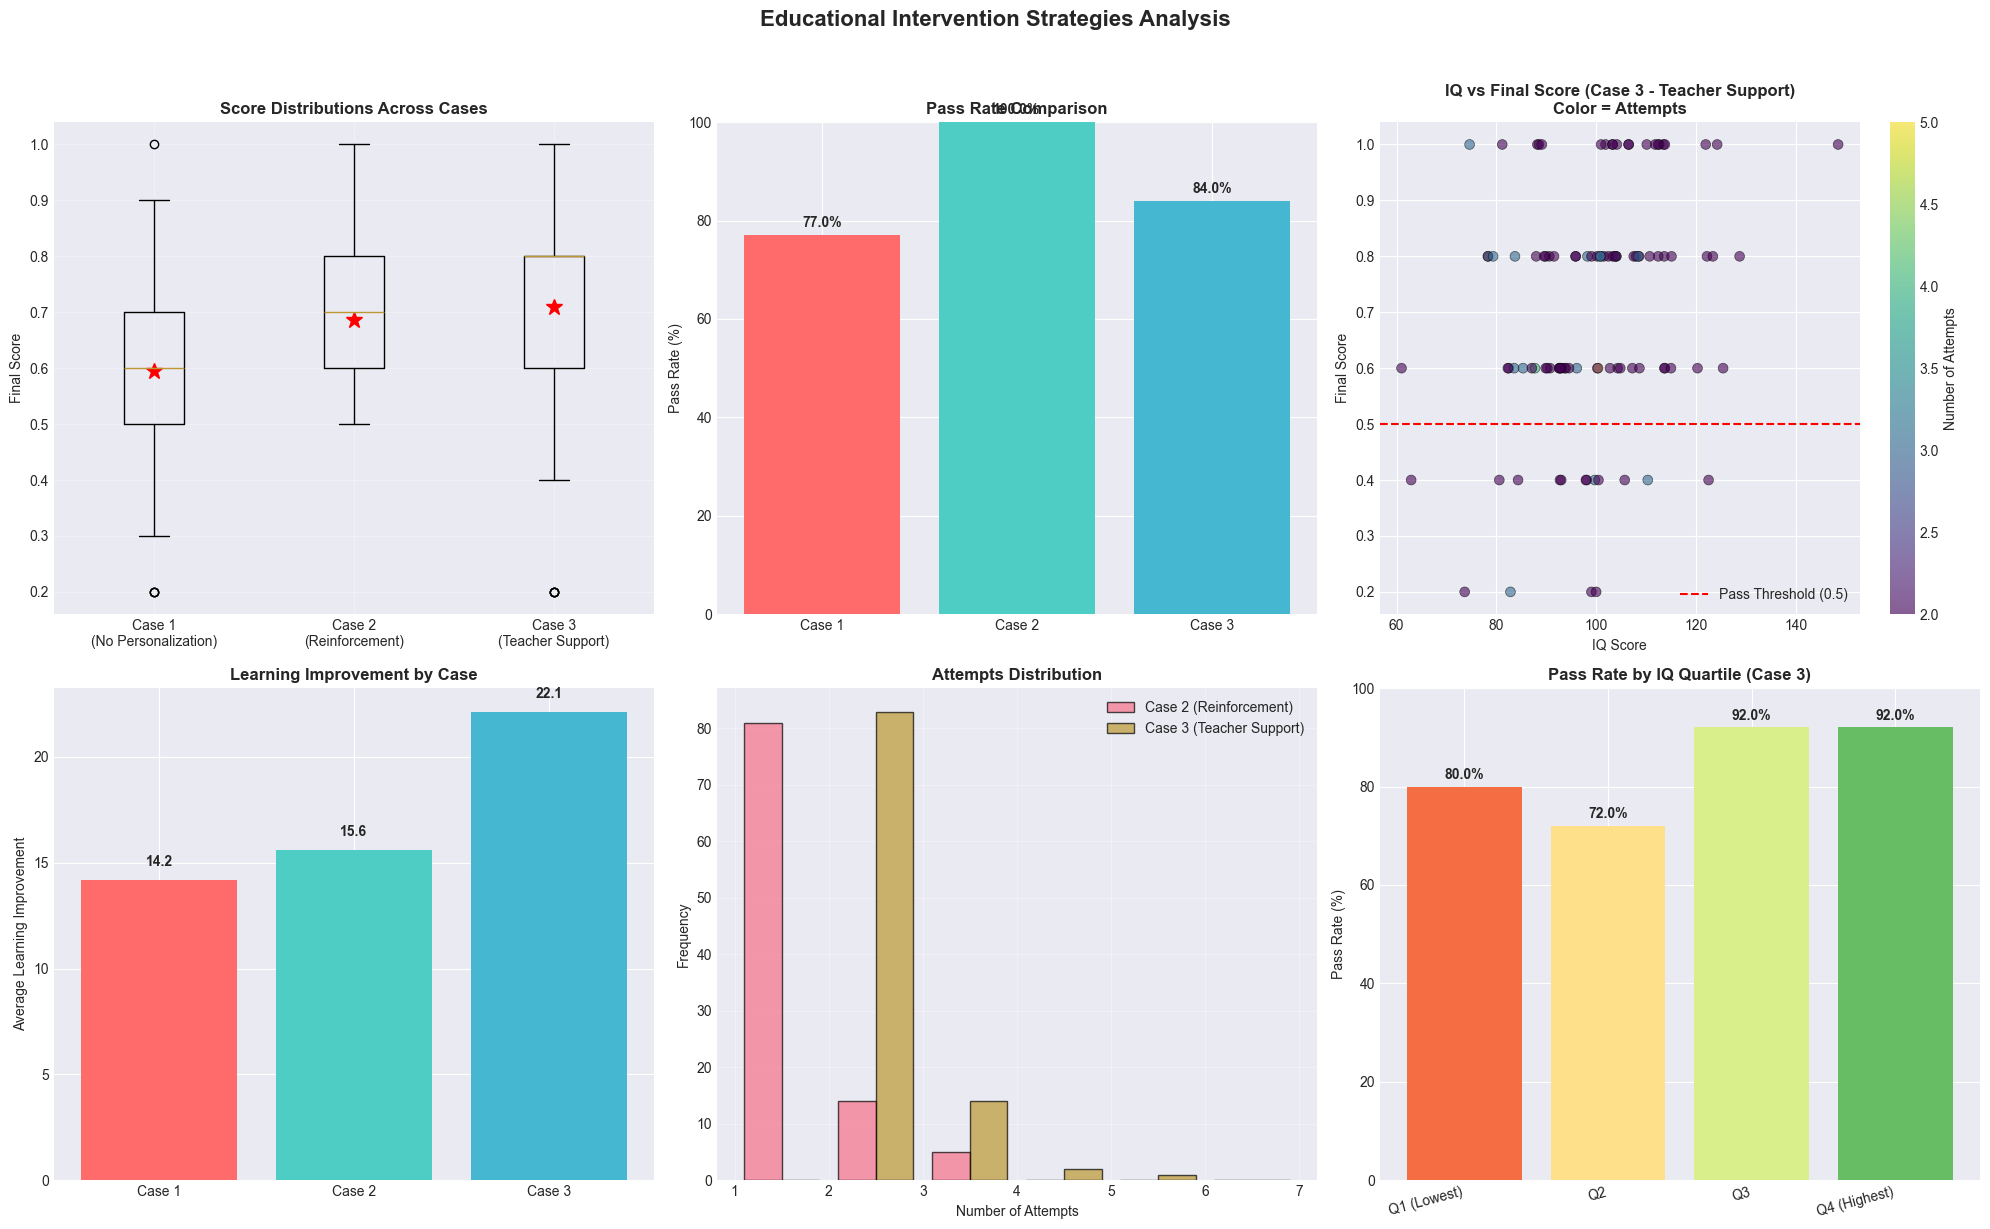


STATISTICAL SUMMARY
       Metric Case 1 Case 2 Case 3
   Mean Score  0.595  0.686  0.710
 Median Score  0.600  0.700  0.800
    Std Score  0.172  0.143  0.215
Pass Rate (%)  77.0% 100.0%  84.0%
Mean Learning   64.2   65.6   72.1
Mean Attempts    N/A   1.24   2.21


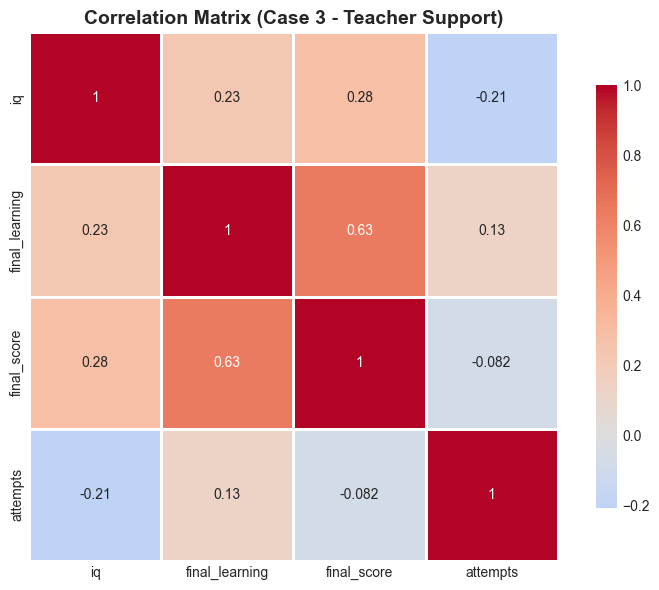

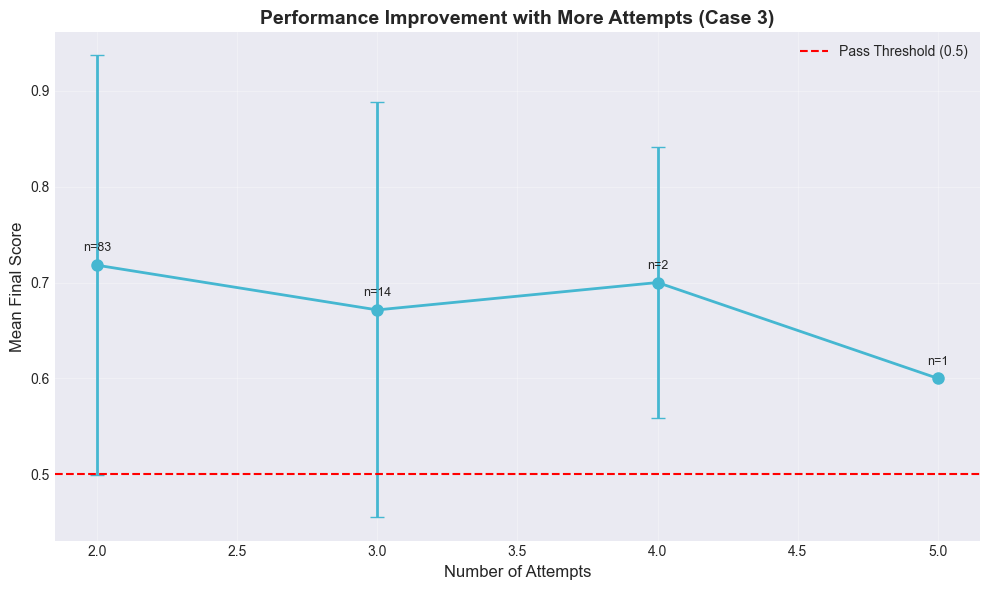

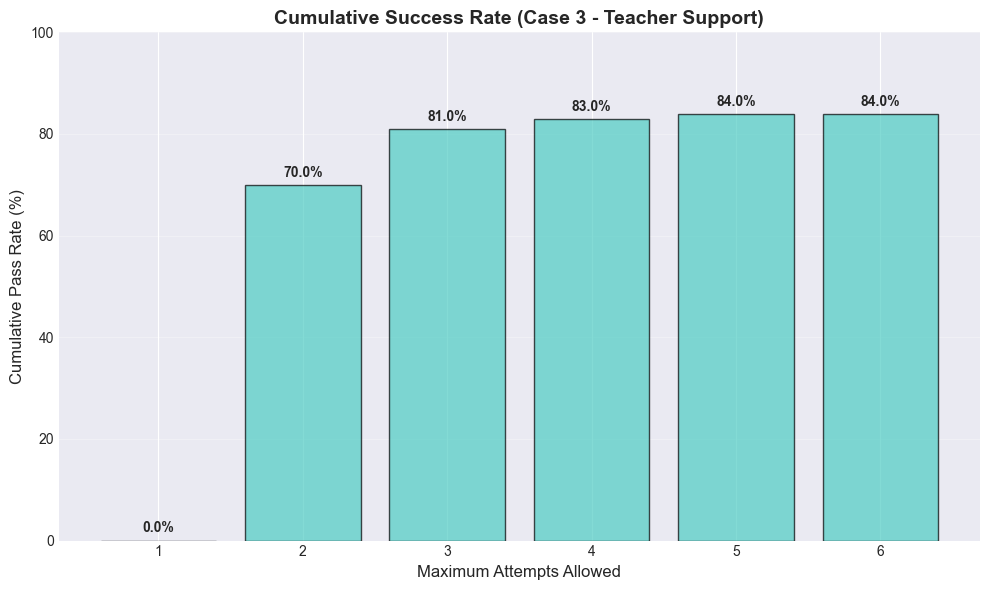


KEY INSIGHTS
1. Best improvement: Case 3 improved pass rate by 7.0% over baseline
2. Most efficient: Case 3 required only 2.2 attempts on average
3. Learning boost: Case 3 students gained 22.1 points vs 14.2 in baseline
4. IQ correlation: 0.285 correlation between IQ and final score


In [795]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Create figure for multiple visualizations
fig = plt.figure(figsize=(20, 12))

# 1. Score Distributions Comparison
ax1 = plt.subplot(2, 3, 1)
scores_data = [df_c1['final_score'], df_c2['final_score'], df_c3['final_score']]
boxes = ax1.boxplot(scores_data, labels=['Case 1\n(No Personalization)', 
                                          'Case 2\n(Reinforcement)', 
                                          'Case 3\n(Teacher Support)'])
ax1.set_ylabel('Final Score')
ax1.set_title('Score Distributions Across Cases', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)

# Add mean points
means = [df_c1['final_score'].mean(), df_c2['final_score'].mean(), df_c3['final_score'].mean()]
for i, mean in enumerate(means, 1):
    ax1.plot(i, mean, 'r*', markersize=12, label='Mean' if i==1 else '')

# 2. Pass Rates Comparison
ax2 = plt.subplot(2, 3, 2)
pass_rates = [
    df_c1['passed'].mean() * 100,
    df_c2['passed'].mean() * 100,
    df_c3['passed'].mean() * 100
]
bars = ax2.bar(['Case 1', 'Case 2', 'Case 3'], pass_rates, 
                color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
ax2.set_ylabel('Pass Rate (%)')
ax2.set_title('Pass Rate Comparison', fontsize=12, fontweight='bold')
ax2.set_ylim([0, 100])

# Add value labels on bars
for bar, rate in zip(bars, pass_rates):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{rate:.1f}%', ha='center', va='bottom', fontweight='bold')

# 3. IQ vs Final Score Scatter (Case 3 - most interesting)
ax3 = plt.subplot(2, 3, 3)
scatter = ax3.scatter(df_c3['iq'], df_c3['final_score'], 
                      c=df_c3['attempts'], cmap='viridis', 
                      alpha=0.6, s=50, edgecolors='black', linewidth=0.5)
ax3.set_xlabel('IQ Score')
ax3.set_ylabel('Final Score')
ax3.set_title('IQ vs Final Score (Case 3 - Teacher Support)\nColor = Attempts', 
              fontsize=12, fontweight='bold')
ax3.axhline(y=PASS_THRESHOLD, color='red', linestyle='--', 
            label=f'Pass Threshold ({PASS_THRESHOLD})')
ax3.legend()
plt.colorbar(scatter, ax=ax3, label='Number of Attempts')

# 4. Learning Improvement Across Cases
ax4 = plt.subplot(2, 3, 4)
initial_learning = 50  # Initial learning value from generate_students
learning_improvements = [
    df_c1['final_learning'].mean() - initial_learning,
    df_c2['final_learning'].mean() - initial_learning,
    df_c3['final_learning'].mean() - initial_learning
]
bars = ax4.bar(['Case 1', 'Case 2', 'Case 3'], learning_improvements,
                color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
ax4.set_ylabel('Average Learning Improvement')
ax4.set_title('Learning Improvement by Case', fontsize=12, fontweight='bold')

for bar, improvement in zip(bars, learning_improvements):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{improvement:.1f}', ha='center', va='bottom', fontweight='bold')

# 5. Attempts Distribution (Cases 2 & 3)
ax5 = plt.subplot(2, 3, 5)
attempts_data = [df_c2['attempts'], df_c3['attempts']]
ax5.hist(attempts_data, bins=range(1, 8), alpha=0.7, 
         label=['Case 2 (Reinforcement)', 'Case 3 (Teacher Support)'],
         edgecolor='black')
ax5.set_xlabel('Number of Attempts')
ax5.set_ylabel('Frequency')
ax5.set_title('Attempts Distribution', fontsize=12, fontweight='bold')
ax5.legend()
ax5.grid(True, alpha=0.3)

# 6. Performance by IQ Quartile (Case 3)
ax6 = plt.subplot(2, 3, 6)
iq_quartiles = pd.qcut(df_c3['iq'], q=4, labels=['Q1 (Lowest)', 'Q2', 'Q3', 'Q4 (Highest)'])
pass_by_quartile = df_c3.groupby(iq_quartiles)['passed'].mean() * 100
bars = ax6.bar(range(len(pass_by_quartile)), pass_by_quartile.values,
                color=plt.cm.RdYlGn(np.linspace(0.2, 0.8, 4)))
ax6.set_xticks(range(len(pass_by_quartile)))
ax6.set_xticklabels(pass_by_quartile.index, rotation=15, ha='right')
ax6.set_ylabel('Pass Rate (%)')
ax6.set_title('Pass Rate by IQ Quartile (Case 3)', fontsize=12, fontweight='bold')
ax6.set_ylim([0, 100])

for bar, rate in zip(bars, pass_by_quartile.values):
    ax6.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{rate:.1f}%', ha='center', va='bottom', fontweight='bold')

plt.suptitle('Educational Intervention Strategies Analysis', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Additional Analysis - Statistical Summary
print("\n" + "="*60)
print("STATISTICAL SUMMARY")
print("="*60)

summary_stats = pd.DataFrame({
    'Metric': ['Mean Score', 'Median Score', 'Std Score', 'Pass Rate (%)', 
               'Mean Learning', 'Mean Attempts'],
    'Case 1': [
        f"{df_c1['final_score'].mean():.3f}",
        f"{df_c1['final_score'].median():.3f}",
        f"{df_c1['final_score'].std():.3f}",
        f"{df_c1['passed'].mean()*100:.1f}%",
        f"{df_c1['final_learning'].mean():.1f}",
        "N/A"
    ],
    'Case 2': [
        f"{df_c2['final_score'].mean():.3f}",
        f"{df_c2['final_score'].median():.3f}",
        f"{df_c2['final_score'].std():.3f}",
        f"{df_c2['passed'].mean()*100:.1f}%",
        f"{df_c2['final_learning'].mean():.1f}",
        f"{df_c2['attempts'].mean():.2f}"
    ],
    'Case 3': [
        f"{df_c3['final_score'].mean():.3f}",
        f"{df_c3['final_score'].median():.3f}",
        f"{df_c3['final_score'].std():.3f}",
        f"{df_c3['passed'].mean()*100:.1f}%",
        f"{df_c3['final_learning'].mean():.1f}",
        f"{df_c3['attempts'].mean():.2f}"
    ]
})

print(summary_stats.to_string(index=False))

# Heatmap of correlations (Case 3)
fig2, ax = plt.subplots(figsize=(8, 6))
correlation_data = df_c3[['iq', 'final_learning', 'final_score', 'attempts']]
correlation_matrix = correlation_data.corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title('Correlation Matrix (Case 3 - Teacher Support)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Improvement visualization over attempts (Case 3)
fig3, ax = plt.subplots(figsize=(10, 6))

# Group by attempts and calculate mean score
attempts_grouped = df_c3.groupby('attempts')['final_score'].agg(['mean', 'std', 'count']).reset_index()

ax.errorbar(attempts_grouped['attempts'], attempts_grouped['mean'], 
            yerr=attempts_grouped['std'], fmt='o-', capsize=5, 
            markersize=8, linewidth=2, color='#45B7D1')
ax.set_xlabel('Number of Attempts', fontsize=12)
ax.set_ylabel('Mean Final Score', fontsize=12)
ax.set_title('Performance Improvement with More Attempts (Case 3)', 
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.axhline(y=PASS_THRESHOLD, color='red', linestyle='--', 
           label=f'Pass Threshold ({PASS_THRESHOLD})')
ax.legend()

# Add sample size annotations
for idx, row in attempts_grouped.iterrows():
    ax.annotate(f'n={int(row["count"])}', 
                (row['attempts'], row['mean']),
                textcoords="offset points", xytext=(0,10), 
                ha='center', fontsize=9)

plt.tight_layout()
plt.show()

# Cumulative pass rate over attempts (Case 3)
fig4, ax = plt.subplots(figsize=(10, 6))

# Calculate cumulative pass rate
attempt_counts = df_c3['attempts'].value_counts().sort_index()
cumulative_passes = []
total_students = len(df_c3)

for attempt in range(1, 7):
    passed_in_attempts = df_c3[df_c3['attempts'] <= attempt]['passed'].sum()
    cumulative_passes.append(passed_in_attempts / total_students * 100)

ax.bar(range(1, 7), cumulative_passes, color='#4ECDC4', alpha=0.7, edgecolor='black')
ax.set_xlabel('Maximum Attempts Allowed', fontsize=12)
ax.set_ylabel('Cumulative Pass Rate (%)', fontsize=12)
ax.set_title('Cumulative Success Rate (Case 3 - Teacher Support)', 
             fontsize=14, fontweight='bold')
ax.set_xticks(range(1, 7))
ax.set_ylim([0, 100])

# Add value labels
for i, rate in enumerate(cumulative_passes, 1):
    ax.text(i, rate + 1, f'{rate:.1f}%', ha='center', va='bottom', fontweight='bold')

ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("KEY INSIGHTS")
print("="*60)
print(f"1. Best improvement: Case 3 improved pass rate by {pass_rates[2]-pass_rates[0]:.1f}% over baseline")
print(f"2. Most efficient: Case 3 required only {df_c3['attempts'].mean():.1f} attempts on average")
print(f"3. Learning boost: Case 3 students gained {learning_improvements[2]:.1f} points vs {learning_improvements[0]:.1f} in baseline")
print(f"4. IQ correlation: {correlation_matrix.loc['iq', 'final_score']:.3f} correlation between IQ and final score")